# Voyage Analytics — Data Validation

**Notebook:** `05_Data_Validation` · **Pipeline stages:** `validate` (1st) and `audit` (4th)
**Module:** `src/validation/validation.py` · **Produces:** `reports/data_quality_report.json`

---

### Why validation is its own stage
Data quality checks used to live inside ingestion. They now sit in their own module because they do
two jobs at **two different points** in the pipeline:

```
data/raw/*.csv
    │
    ▼  ① validate  ── gate: schema · bounds · referential ──▶ stop the run if raw data is broken
    │
  ingest ──▶ data/interim + data/processed
    │
  features ──▶ feature sets
    │
    ▼  ② audit ──── verify what we wrote: files · key columns · business invariants
    │
  train
```

Coupling this to ingestion made the second job impossible — you cannot audit the outputs from inside
the step that produces them. Separating it also matches the **Data Validation** box in the system
design (the role Great Expectations fills in the target architecture), and lets the checks be swapped
or extended without touching transformation code.

### Severity model
| Severity | Examples | Effect |
|---|---|---|
| **error** | missing column, value out of bounds, orphan foreign key, empty table | **stops the pipeline** |
| **warning** | nulls, duplicate rows, unseen category value | recorded, run continues |

Errors are things that would silently corrupt downstream models; warnings are things a human should
see but that do not invalidate the data.


## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
PAL = ["#0B6E4F", "#F2C14E", "#B4436C"]

from src.utils import PATHS
print("raw      :", PATHS.raw)
print("reports  :", PATHS.reports)

raw      : F:\Final Project Labmentix\voyage-analytics\data\raw
reports  : F:\Final Project Labmentix\voyage-analytics\reports


## 1. Scope 1 — validating the raw data (the gate)

Six families of checks run over `flights.csv`, `hotels.csv` and `users.csv`:

| Check | What it catches | Severity |
|---|---|---|
| schema | a column renamed or dropped upstream | error |
| bounds | negative prices, impossible ages | error |
| referential | a booking for a user who doesn't exist | error |
| nulls | missing values | warning |
| duplicates | repeated rows | warning |
| domains | a new flight class or agency appearing | warning |


In [2]:
from src.validation import validate_raw

raw_report = validate_raw()
print(raw_report.summary())
print("\nstats:")
for tbl, s in raw_report.stats.items():
    print(f"  {tbl:<8} {s['rows']:>7,} rows x {s['cols']} cols")

17:25:11 | INFO    | validation | validation[raw]: PASS | 22 passed, 0 error(s), 0 warning(s)


validation[raw]: PASS | 22 passed, 0 error(s), 0 warning(s)

stats:
  flights  271,888 rows x 10 cols
  hotels    40,552 rows x 8 cols
  users      1,340 rows x 5 cols


In [3]:
display(raw_report.to_frame().head(30))

,severity,message
0,passed,[flights] schema: all 10 expected columns present
1,passed,[flights] nulls: none
2,passed,[flights] duplicates: none
3,passed,[flights] 'flightType' domain: within ['econom...
4,passed,"[flights] 'agency' domain: within ['CloudFy', ..."
5,passed,"[flights] 'price' within [0, 5000]"
6,passed,"[flights] 'time' within [0, 10]"
7,passed,"[flights] 'distance' within [0, 3000]"
8,passed,[hotels] schema: all 8 expected columns present
9,passed,[hotels] nulls: none


**Result.** The raw data passes cleanly — **0 errors, 0 warnings**. No nulls, no duplicate rows,
every categorical value inside its known domain, every numeric inside sane bounds, and every
`userCode`/`travelCode` resolving to a real parent record.

That is unusually clean, and the checks exist precisely so we would *know* if that ever stopped being
true — for example if a refreshed extract introduced a fourth flight class or a booking for a deleted
user. The gate turns a silent downstream failure into an explicit, early one.

## 2. Scope 2 — auditing what the pipeline produced

The second scope checks the nine tables written to `data/interim` and `data/processed`: that each
file exists and is non-empty, that its key columns survived, and that the **business invariants**
established during EDA still hold after all the transformations.

In [4]:
from src.validation import validate_processed, EXPECTED_TABLES

print("tables under audit:")
for group, tables in EXPECTED_TABLES.items():
    for stem in tables:
        print(f"  {group:<10} {stem}")

tables under audit:
  interim    flights_clean
  interim    hotels_clean
  interim    users_clean
  processed  trips
  processed  users_features
  processed  flight_price_model
  processed  gender_features
  processed  user_hotel_interactions
  processed  hotel_catalog


In [5]:
proc_report = validate_processed()
print(proc_report.summary())

17:25:13 | INFO    | validation | validation[processed]: PASS | 25 passed, 0 error(s), 0 warning(s)


validation[processed]: PASS | 25 passed, 0 error(s), 0 warning(s)


In [6]:
display(proc_report.to_frame().head(40))

,severity,message
0,passed,"[flights_clean] present, 271,888 rows"
1,passed,[flights_clean] key columns intact
2,passed,"[hotels_clean] present, 40,552 rows"
3,passed,[hotels_clean] key columns intact
4,passed,"[users_clean] present, 1,340 rows"
5,passed,[users_clean] key columns intact
6,passed,"[trips] present, 135,944 rows"
7,passed,[trips] key columns intact
8,passed,"[users_features] present, 1,340 rows"
9,passed,[users_features] key columns intact


### The business invariants
These are the structural facts EDA established. If a refactor ever breaks one, the audit fails loudly
instead of quietly shipping wrong features:

| Invariant | Why it matters |
|---|---|
| every `travelCode` has exactly **2 flight legs** | the round-trip assumption `build_trips()` relies on |
| `hotels.total == price × days` | guards the spend calculations |
| `trip_nights` within **1–4** | the observed range; drift here signals a join bug |
| no negative `trip_spend` | a sign flip would corrupt every RFM feature |
| `flight_price_model.price` positive, non-null | the regression target must be usable |
| every `trips.user` exists in `users_features` | join integrity across processed tables |
| `gender_features` has labelled rows | the classifier needs a train pool |


## 3. Both scopes at once + the saved report

In [7]:
from src.validation import run_validation, REPORT_PATH

reports = run_validation(scope="all", strict=False)   # strict=False: report, don't raise
for scope, r in reports.items():
    print(f"{scope:<10} {r.summary()}")
print("\nsaved to:", REPORT_PATH.relative_to(PATHS.root))

17:25:13 | INFO    | validation | === data validation started (scope=all) ===


17:25:14 | INFO    | validation | validation[raw]: PASS | 22 passed, 0 error(s), 0 warning(s)


17:25:16 | INFO    | validation | validation[processed]: PASS | 25 passed, 0 error(s), 0 warning(s)


17:25:16 | INFO    | validation | saved report -> F:\Final Project Labmentix\voyage-analytics\reports\data_quality_report.json


17:25:16 | INFO    | validation | === data validation complete ===


raw        validation[raw]: PASS | 22 passed, 0 error(s), 0 warning(s)
processed  validation[processed]: PASS | 25 passed, 0 error(s), 0 warning(s)

saved to: reports\data_quality_report.json


,scope,passed,warnings,errors
0,raw,22,0,0
1,processed,25,0,0


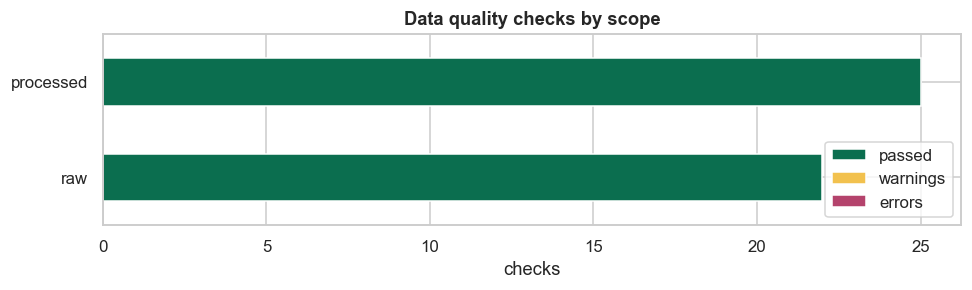

In [8]:
summary = pd.DataFrame([
    {"scope": s, "passed": len(r.passed), "warnings": len(r.warnings), "errors": len(r.errors)}
    for s, r in reports.items()
])
display(summary)

ax = summary.set_index("scope")[["passed", "warnings", "errors"]].plot(
    kind="barh", stacked=True, figsize=(9, 2.8), color=PAL)
ax.set_title("Data quality checks by scope"); ax.set_xlabel("checks"); ax.set_ylabel("")
plt.tight_layout()
PATHS.figures.mkdir(parents=True, exist_ok=True)
plt.savefig(PATHS.figures / "22_validation_summary.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Using it as a gate

In the pipeline the checks run with `strict=True`, so an error raises and `main.py` stops the run
rather than letting a later stage train on bad data.

In [9]:
# Demonstrate the gate on a deliberately corrupted frame — the raw files are untouched.
from src.validation import load_raw_frames, validate_raw

frames = load_raw_frames()
broken = {k: v.copy() for k, v in frames.items()}
broken["flights"].loc[0, "price"] = -999            # violates the bounds rule
broken["hotels"].loc[0, "userCode"] = 999_999       # orphan foreign key

bad = validate_raw(broken)
print(bad.summary())
for e in bad.errors:
    print("  ERROR:", e)

17:25:20 | ERROR   | validation | [flights] 'price' has 1 value(s) outside [0, 5000]


17:25:20 | ERROR   | validation | [hotels] 1 userCode(s) not present in users


17:25:20 | INFO    | validation | validation[raw]: FAIL | 20 passed, 2 error(s), 0 warning(s)


validation[raw]: FAIL | 20 passed, 2 error(s), 0 warning(s)
  ERROR: [flights] 'price' has 1 value(s) outside [0, 5000]
  ERROR: [hotels] 1 userCode(s) not present in users


**Insight.** Both injected faults are caught: the negative fare trips the bounds check and the
orphan `userCode` trips the referential check — each an *error*, so the pipeline would halt here.

This is the point of the stage. A negative price would otherwise flow into the regressor's target and
quietly degrade it; an orphan booking would produce a silent `NaN` after the user join. Catching them
at the boundary is far cheaper than debugging a model that trained on them.

## 5. Summary

**Module:** `src/validation/` — the same one-module-in-a-package layout as `data_ingestion` and
`features`.

```bash
python -m src.validation                    # raw scope (the gate)
python -m src.validation --scope processed  # audit generated tables
python -m src.validation --scope all
python -m src.validation --no-strict        # report without raising
```

**In the pipeline** (`main.py`) it appears twice:

| Stage | Scope | Role |
|---|---|---|
| `validate` (1st) | raw | gate the input before anything is cleaned |
| `audit` (4th) | processed | verify every table the pipeline wrote |

**Outcome:** raw data passes with 0 errors / 0 warnings; all nine generated tables pass their
structural and business-invariant checks. The full report is written to
`reports/data_quality_report.json` on every run, giving each pipeline execution an auditable record.

**Next step for this stage:** swap the hand-rolled checks for **Great Expectations** suites, as the
system design specifies — the interface (`run_validation(scope, strict)`) stays the same, so nothing
else in the pipeline has to change.

---
*End of data validation.*
